<a href="https://colab.research.google.com/github/jamie07262/INFO-3608-PROJECT/blob/main/New_Data_Processor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import re
import tqdm
import shutil
import requests
import numpy as np
import pandas as pd
import seaborn as sb
from pathlib import Path
import statsmodels.api as sm
from google.colab import drive
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score

In [ ]:
# GitHub API URL for the directory
api_url = "https://api.github.com/repos/jamie07262/INFO-3608-PROJECT/contents/data/raw"

# Create local directory
os.makedirs("raw", exist_ok=True)

# Get list of files from GitHub API
response = requests.get(api_url)
if response.status_code == 200:
    files = response.json()
    for file in files:
        if file['name'].endswith('.csv'):
            download_url = file['download_url']
            r = requests.get(download_url)
            with open(f"raw/{file['name']}", "wb") as f:
                f.write(r.content)
            print(f"Downloaded: {file['name']}")
else:
    print(f"Failed to access API: {response.status_code}")

print("All CSV files downloaded.")

Downloaded: 538ratingsMen.csv
Downloaded: 538ratingsWomen.csv
Downloaded: Cities.csv
Downloaded: Conferences.csv
Downloaded: MConferenceTourneyGames.csv
Downloaded: MGameCities.csv
Downloaded: MMasseyOrdinalsPart1.csv
Downloaded: MMasseyOrdinalsPart2.csv
Downloaded: MNCAATourneyCompactResults.csv
Downloaded: MNCAATourneyDetailedResults.csv
Downloaded: MNCAATourneySeedRoundSlots.csv
Downloaded: MNCAATourneySeeds.csv
Downloaded: MNCAATourneySlots.csv
Downloaded: MRegularSeasonCompactResults.csv
Downloaded: MRegularSeasonDetailedResults.csv
Downloaded: MSeasons.csv
Downloaded: MSecondaryTourneyCompactResults.csv
Downloaded: MSecondaryTourneyTeams.csv
Downloaded: MTeamCoaches.csv
Downloaded: MTeamConferences.csv
Downloaded: MTeamSpellings.csv
Downloaded: MTeams.csv
Downloaded: SampleSubmissionStage1.csv
Downloaded: SampleSubmissionStage2.csv
Downloaded: SeedBenchmarkStage1.csv
Downloaded: WConferenceTourneyGames.csv
Downloaded: WGameCities.csv
Downloaded: WNCAATourneyCompactResults.csv
Dow

In [ ]:
#Read and Merge data

seasonResults = pd.concat(
    [
        pd.read_csv("raw/MRegularSeasonDetailedResults.csv").assign(Divison = 1),
        pd.read_csv("raw/WRegularSeasonDetailedResults.csv").assign(Divison = 0),
    ]
).reset_index(drop=True)

tourneyResults = pd.concat(
    [
        pd.read_csv("raw/MNCAATourneyDetailedResults.csv").assign(Divison = 1),
        pd.read_csv("raw/WNCAATourneyDetailedResults.csv").assign(Divison = 0),
    ]
).reset_index(drop=True)

seeds = pd.concat(
    [
        pd.read_csv("raw/MNCAATourneySeeds.csv").assign(Divison = 1),
        pd.read_csv("raw/WNCAATourneySeeds.csv").assign(Divison = 0),
    ]
).reset_index(drop=True)

In [ ]:
pd.options.display.max_columns = None

In [ ]:
seasonResults

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,Divison
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20,1
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16,1
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23,1
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23,1
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200585,2025,131,3471,75,3413,66,A,0,26,62,4,19,19,28,8,31,10,11,6,1,20,24,67,9,29,9,14,9,26,14,10,6,5,22,0
200586,2025,132,3192,66,3476,49,H,0,23,55,3,21,17,18,10,22,11,9,8,1,8,21,57,4,20,3,4,14,22,14,17,4,1,17,0
200587,2025,132,3250,74,3119,62,H,0,27,45,5,14,15,17,5,25,15,15,6,0,12,25,56,6,17,6,10,8,13,10,10,5,0,20,0
200588,2025,132,3293,83,3125,62,N,0,28,54,14,28,13,15,5,33,21,13,2,3,15,24,68,2,21,12,14,12,22,11,7,5,0,16,0


In [ ]:
tourneyResults

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,Divison
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22,1
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15,1
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18,1
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21,1
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271,2024,147,3163,80,3425,73,A,0,28,58,7,15,17,27,5,30,17,12,6,5,21,23,70,9,29,18,20,10,25,10,9,6,4,20,0
2272,2024,147,3234,94,3261,87,H,0,32,69,13,31,17,22,3,29,16,11,6,3,15,34,88,8,24,11,17,21,28,15,13,6,6,21,0
2273,2024,151,3234,71,3163,69,N,0,27,59,7,25,10,14,9,23,12,16,7,1,9,29,63,8,25,3,4,6,22,21,14,15,1,18,0
2274,2024,151,3376,78,3301,59,N,0,33,66,8,19,4,4,10,34,18,15,10,6,16,20,62,6,23,13,18,10,18,5,12,9,1,9,0


In [ ]:
seeds

,Season,Seed,TeamID,Divison
0,1985,W01,1207,1
1,1985,W02,1210,1
2,1985,W03,1228,1
3,1985,W04,1260,1
4,1985,W05,1374,1
...,...,...,...,...
4365,2025,Z12,3193,0
4366,2025,Z13,3251,0
4367,2025,Z14,3195,0
4368,2025,Z15,3117,0


In [ ]:
#Remove seeds before 2003 to match season and tourney
seeds = seeds.loc[seeds["Season"] >= 2003]

In [ ]:
seeds

,Season,Seed,TeamID,Divison
1154,2003,W01,1328,1
1155,2003,W02,1448,1
1156,2003,W03,1393,1
1157,2003,W04,1257,1
1158,2003,W05,1280,1
...,...,...,...,...
4365,2025,Z12,3193,0
4366,2025,Z13,3251,0
4367,2025,Z14,3195,0
4368,2025,Z15,3117,0


# Data Explination:

Team Box Scores are provided in "Detailed Results" files rather than "Compact Results" files. However, the two files are strongly related.
In a Detailed Results file, the first eight columns (Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, and NumOT) are exactly the same as a Compact Results file. However, in a Detailed Results file, there are many additional columns. The column names should be self-explanatory to basketball fans (as above, "W" or "L" refers to the winning or losing team):

    WFGM - field goals made (by the winning team)
    WFGA - field goals attempted (by the winning team)
    WFGM3 - three pointers made (by the winning team)
    WFGA3 - three pointers attempted (by the winning team)
    WFTM - free throws made (by the winning team)
    WFTA - free throws attempted (by the winning team)
    WOR - offensive rebounds (pulled by the winning team)
    WDR - defensive rebounds (pulled by the winning team)
    WAst - assists (by the winning team)
    WTO - turnovers committed (by the winning team)
    WStl - steals (accomplished by the winning team)
    WBlk - blocks (accomplished by the winning team)
    WPF - personal fouls committed (by the winning team)

(and then the same set of stats from the perspective of the losing team: LFGM is the number of field goals made by the losing team, and so on up to LPF).

In [ ]:
#Reverse team positions in box scores
def prepareData(dataFrame):
    dataFrame = dataFrame[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF", "Divison"]].copy()


    #Adjustments for Overtime (Since more time = more stats)
    overtimeAdjustment = (40 + 5 * dataFrame["NumOT"]) / 40
    columnAdjustments = ["LScore", "WScore",
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF", "Divison"]
    for col in columnAdjustments:
        dataFrame[col] = dataFrame[col] / overtimeAdjustment

    dataFrameSwap = dataFrame.copy()
    dataFrame.columns = [x.replace("W", "T1").replace("L", "T2") for x in list(dataFrame.columns)]
    dataFrameSwap.columns = [x.replace("L", "T1").replace("W", "T2") for x in list(dataFrameSwap.columns)]
    final = pd.concat([dataFrame, dataFrameSwap]).reset_index(drop=True)
    final["PointDifference"] = final["T1Score"] - final["T2Score"]
    final["Win"] = (final["PointDifference"] > 0) * 1
    final["Divison"] = (final["T1TeamID"].apply(lambda t: str(t).startswith("1"))) * 1

    return final

seasonData = prepareData(seasonResults)
tourneyData = prepareData(tourneyResults)

In [ ]:
seasonData

,Season,DayNum,T2TeamID,T2Score,T1TeamID,T1Score,NumOT,T2FGM,T2FGA,T2FGM3,T2FGA3,T2FTM,T2FTA,T2OR,T2DR,T2Ast,T2TO,T2Stl,T2Blk,T2PF,T1FGM,T1FGA,T1FGM3,T1FGA3,T1FTM,T1FTA,T1OR,T1DR,T1Ast,T1TO,T1Stl,T1Blk,T1PF,Divison,PointDifference,Win
0,2003,10,1328,62.0,1104,68.0,0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,1,6.0,1
1,2003,10,1393,63.0,1272,70.0,0,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,1,7.0,1
2,2003,11,1437,61.0,1266,73.0,0,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,1,12.0,1
3,2003,11,1457,50.0,1296,56.0,0,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,1,6.0,1
4,2003,11,1208,71.0,1400,77.0,0,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,1,6.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401175,2025,131,3471,75.0,3413,66.0,0,26.0,62.0,4.0,19.0,19.0,28.0,8.0,31.0,10.0,11.0,6.0,1.0,20.0,24.0,67.0,9.0,29.0,9.0,14.0,9.0,26.0,14.0,10.0,6.0,5.0,22.0,0,-9.0,0
401176,2025,132,3192,66.0,3476,49.0,0,23.0,55.0,3.0,21.0,17.0,18.0,10.0,22.0,11.0,9.0,8.0,1.0,8.0,21.0,57.0,4.0,20.0,3.0,4.0,14.0,22.0,14.0,17.0,4.0,1.0,17.0,0,-17.0,0
401177,2025,132,3250,74.0,3119,62.0,0,27.0,45.0,5.0,14.0,15.0,17.0,5.0,25.0,15.0,15.0,6.0,0.0,12.0,25.0,56.0,6.0,17.0,6.0,10.0,8.0,13.0,10.0,10.0,5.0,0.0,20.0,0,-12.0,0
401178,2025,132,3293,83.0,3125,62.0,0,28.0,54.0,14.0,28.0,13.0,15.0,5.0,33.0,21.0,13.0,2.0,3.0,15.0,24.0,68.0,2.0,21.0,12.0,14.0,12.0,22.0,11.0,7.0,5.0,0.0,16.0,0,-21.0,0


In [ ]:
tourneyData

,Season,DayNum,T2TeamID,T2Score,T1TeamID,T1Score,NumOT,T2FGM,T2FGA,T2FGM3,T2FGA3,T2FTM,T2FTA,T2OR,T2DR,T2Ast,T2TO,T2Stl,T2Blk,T2PF,T1FGM,T1FGA,T1FGM3,T1FGA3,T1FTM,T1FTA,T1OR,T1DR,T1Ast,T1TO,T1Stl,T1Blk,T1PF,Divison,PointDifference,Win
0,2003,134,1411,74.666667,1421,81.777778,1,25.777778,59.555556,10.666667,27.555556,12.444444,27.555556,15.111111,24.888889,14.222222,13.333333,4.444444,0.000000,19.555556,28.444444,61.333333,9.777778,25.777778,15.111111,23.111111,12.444444,26.666667,15.111111,10.666667,4.444444,2.666667,19.555556,1,7.111111,1
1,2003,136,1436,51.000000,1112,80.000000,0,20.000000,64.000000,4.000000,16.000000,7.000000,7.000000,8.000000,26.000000,12.000000,17.000000,10.000000,3.000000,15.000000,31.000000,66.000000,7.000000,23.000000,11.000000,14.000000,11.000000,36.000000,22.000000,16.000000,10.000000,7.000000,8.000000,1,29.000000,1
2,2003,136,1272,71.000000,1113,84.000000,0,25.000000,69.000000,7.000000,28.000000,14.000000,21.000000,20.000000,22.000000,11.000000,12.000000,2.000000,5.000000,18.000000,31.000000,59.000000,6.000000,14.000000,16.000000,22.000000,10.000000,27.000000,18.000000,9.000000,7.000000,4.000000,19.000000,1,13.000000,1
3,2003,136,1166,73.000000,1141,79.000000,0,27.000000,60.000000,7.000000,17.000000,12.000000,17.000000,14.000000,17.000000,20.000000,21.000000,6.000000,6.000000,21.000000,29.000000,53.000000,3.000000,7.000000,18.000000,25.000000,11.000000,20.000000,15.000000,18.000000,13.000000,1.000000,19.000000,1,6.000000,1
4,2003,136,1301,65.777778,1143,67.555556,1,22.222222,49.777778,8.000000,18.666667,13.333333,17.777778,8.888889,23.111111,14.222222,12.444444,4.444444,7.111111,16.888889,24.000000,56.888889,6.222222,17.777778,13.333333,20.444444,16.000000,17.777778,15.111111,11.555556,7.111111,1.777778,12.444444,1,1.777778,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4547,2024,147,3163,80.000000,3425,73.000000,0,28.000000,58.000000,7.000000,15.000000,17.000000,27.000000,5.000000,30.000000,17.000000,12.000000,6.000000,5.000000,21.000000,23.000000,70.000000,9.000000,29.000000,18.000000,20.000000,10.000000,25.000000,10.000000,9.000000,6.000000,4.000000,20.000000,0,-7.000000,0
4548,2024,147,3234,94.000000,3261,87.000000,0,32.000000,69.000000,13.000000,31.000000,17.000000,22.000000,3.000000,29.000000,16.000000,11.000000,6.000000,3.000000,15.000000,34.000000,88.000000,8.000000,24.000000,11.000000,17.000000,21.000000,28.000000,15.000000,13.000000,6.000000,6.000000,21.000000,0,-7.000000,0
4549,2024,151,3234,71.000000,3163,69.000000,0,27.000000,59.000000,7.000000,25.000000,10.000000,14.000000,9.000000,23.000000,12.000000,16.000000,7.000000,1.000000,9.000000,29.000000,63.000000,8.000000,25.000000,3.000000,4.000000,6.000000,22.000000,21.000000,14.000000,15.000000,1.000000,18.000000,0,-2.000000,0
4550,2024,151,3376,78.000000,3301,59.000000,0,33.000000,66.000000,8.000000,19.000000,4.000000,4.000000,10.000000,34.000000,18.000000,15.000000,10.000000,6.000000,16.000000,20.000000,62.000000,6.000000,23.000000,13.000000,18.000000,10.000000,18.000000,5.000000,12.000000,9.000000,1.000000,9.000000,0,-19.000000,0


In [ ]:
#Extract seed number from "Seed" field
seeds["Seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))

<ipython-input-14-5e3b18982414>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seeds["Seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))


In [ ]:
seeds

,Season,Seed,TeamID,Divison
1154,2003,1,1328,1
1155,2003,2,1448,1
1156,2003,3,1393,1
1157,2003,4,1257,1
1158,2003,5,1280,1
...,...,...,...,...
4365,2025,12,3193,0
4366,2025,13,3251,0
4367,2025,14,3195,0
4368,2025,15,3117,0


# Features

1 - Tourney Seed Differences

In [ ]:
#Create a Feature from Seed Differences
seedsW = seeds[["Season", "TeamID", "Seed"]].copy()
seedsL = seeds[["Season", "TeamID", "Seed"]].copy()
seedsW.columns = ["Season", "T1TeamID", "T1Seed"]
seedsL.columns = ["Season", "T2TeamID", "T2Seed"]

tourneyData = tourneyData[["Season", "T1TeamID", "T2TeamID", "PointDifference", "Win", "Divison"]].copy()
tourneyData = pd.merge(tourneyData, seedsW, on=["Season", "T1TeamID"], how="left")
tourneyData = pd.merge(tourneyData, seedsL, on=["Season", "T2TeamID"], how="left")
tourneyData["SeedDifference"] = tourneyData["T2Seed"] - tourneyData["T1Seed"]

In [ ]:
tourneyData

,Season,T1TeamID,T2TeamID,PointDifference,Win,Divison,T1Seed,T2Seed,SeedDifference
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4547,2024,3425,3163,-7.000000,0,0,1,3,2
4548,2024,3261,3234,-7.000000,0,0,3,1,-2
4549,2024,3163,3234,-2.000000,0,0,3,1,-2
4550,2024,3301,3376,-19.000000,0,0,3,1,-2


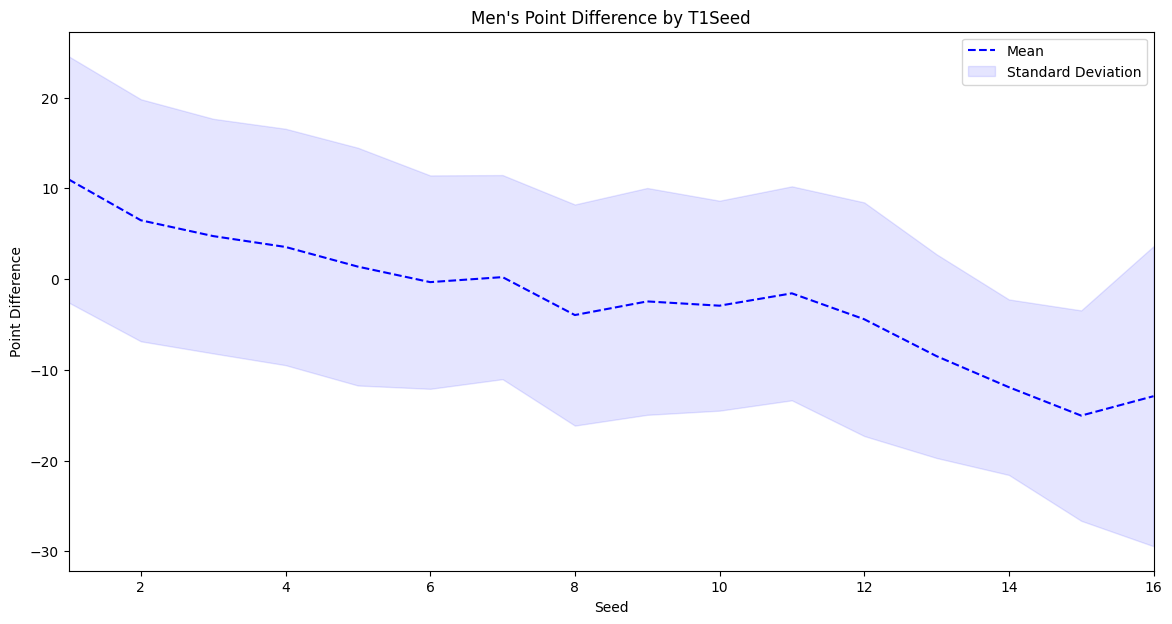

In [ ]:
#Plot Men's Divison PointDifference vs Seed
Data = tourneyData[tourneyData["Divison"] == 1]

mean = Data.pivot_table(index = "T1Seed", values = "PointDifference", aggfunc = "mean").ffill()
std = Data.pivot_table(index = "T1Seed", values = "PointDifference", aggfunc = "std").ffill()

fig, ax = plt.subplots(figsize = (14, 7))
line = ax.plot(mean.index, mean["PointDifference"], "b--", label = "Mean")
fill = ax.fill_between(
    mean.index,
    mean["PointDifference"] - std["PointDifference"],
    mean["PointDifference"] + std["PointDifference"],
    color = "b",
    alpha = 0.1,
    label = "Standard Deviation"
)
ax.set_title("Men's Point Difference by T1Seed")
ax.set_xlabel("Seed")
ax.set_ylabel("Point Difference")
plt.margins(x = 0)
plt.legend()
plt.show()

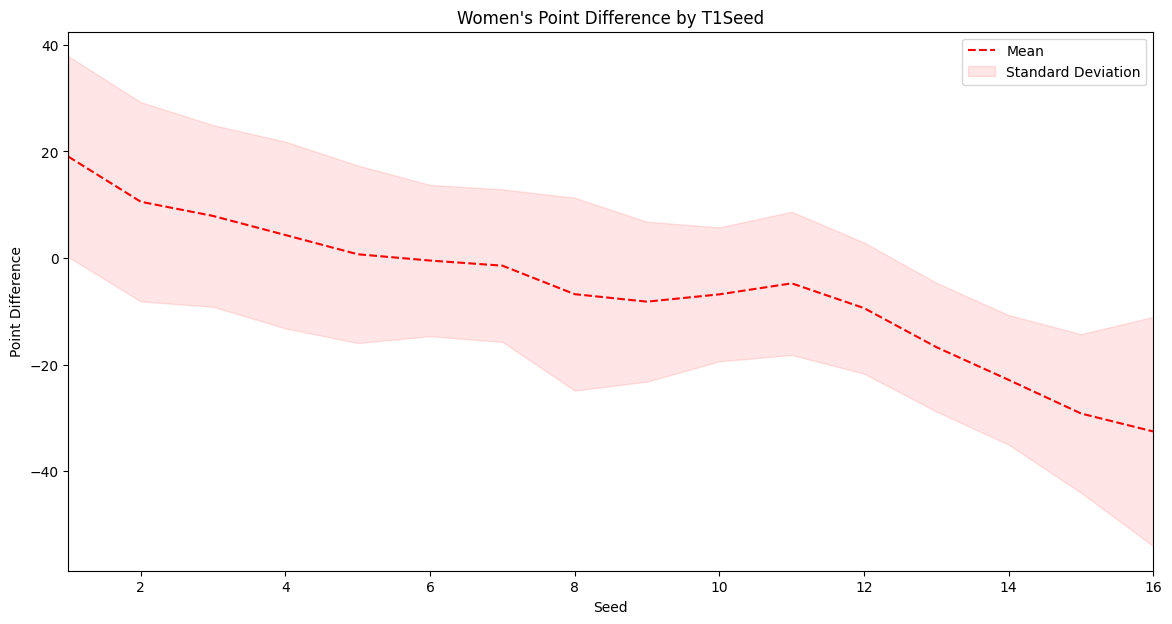

In [ ]:
#Plot Women's Divison PointDifference vs Seed
Data = tourneyData[tourneyData["Divison"] == 0]

mean = Data.pivot_table(index = "T1Seed", values = "PointDifference", aggfunc = "mean").ffill()
std = Data.pivot_table(index = "T1Seed", values = "PointDifference", aggfunc = "std").ffill()

fig, ax = plt.subplots(figsize = (14, 7))
line = ax.plot(mean.index, mean["PointDifference"], "r--", label = "Mean")
fill = ax.fill_between(
    mean.index,
    mean["PointDifference"] - std["PointDifference"],
    mean["PointDifference"] + std["PointDifference"],
    color = "r",
    alpha = 0.1,
    label = "Standard Deviation"
)
ax.set_title("Women's Point Difference by T1Seed")
ax.set_xlabel("Seed")
ax.set_ylabel("Point Difference")
plt.margins(x = 0)
plt.legend()
plt.show()

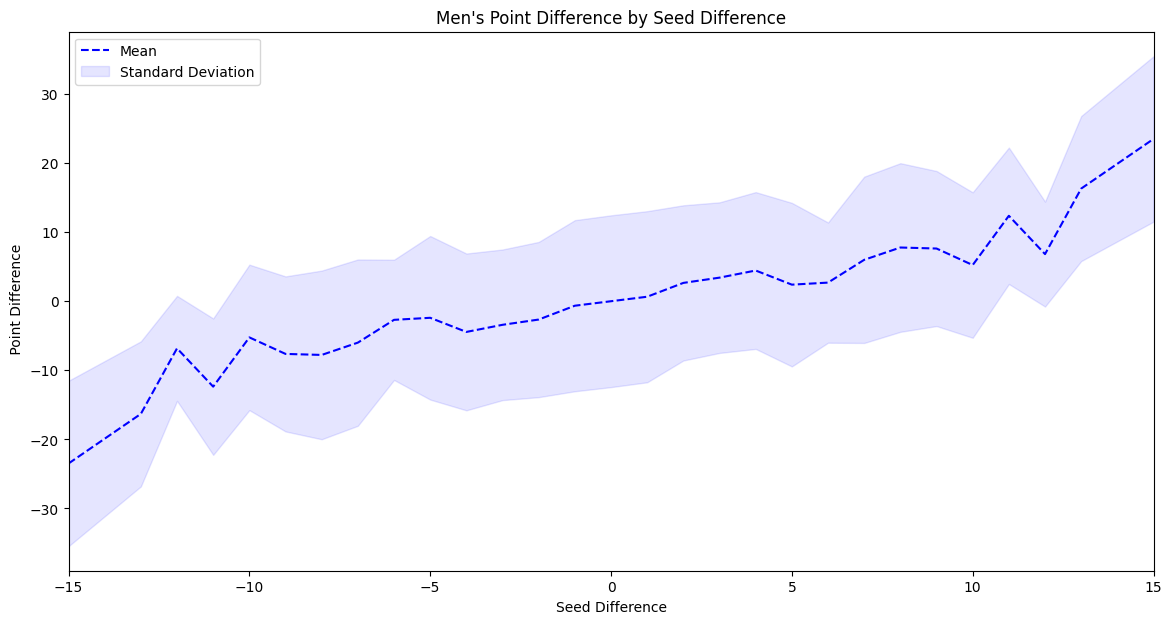

In [ ]:
#Plot Men's Divison PointDifference vs SeedDifference
Data = tourneyData[tourneyData["Divison"] == 1]

mean = Data.pivot_table(index = "SeedDifference", values = "PointDifference", aggfunc = "mean").ffill()
std = Data.pivot_table(index = "SeedDifference", values = "PointDifference", aggfunc = "std").ffill()

fig, ax = plt.subplots(figsize = (14, 7))
line = ax.plot(mean.index, mean["PointDifference"], "b--", label = "Mean")
fill = ax.fill_between(
    mean.index,
    mean["PointDifference"] - std["PointDifference"],
    mean["PointDifference"] + std["PointDifference"],
    color = "b",
    alpha = 0.1,
    label = "Standard Deviation"
)
ax.set_title("Men's Point Difference by Seed Difference")
ax.set_xlabel("Seed Difference")
ax.set_ylabel(" Point Difference")
plt.margins(x = 0)
plt.legend()
plt.show()

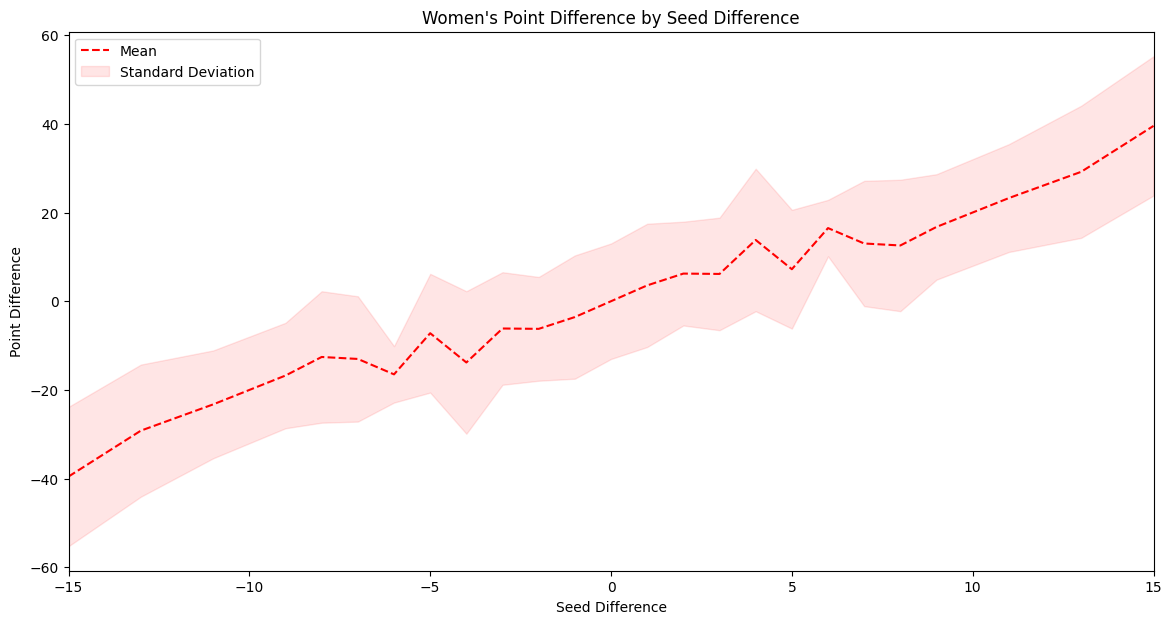

In [ ]:
#Plot Women's Divison PointDifference vs SeedDifference
Data = tourneyData[tourneyData["Divison"] == 0]

mean = (Data.pivot_table(index = "SeedDifference", values = "PointDifference", aggfunc = "mean").ffill())

std = (
    Data.pivot_table(
        index = "SeedDifference",
        values = "PointDifference",
        aggfunc = "std"
        ).interpolate(method="linear").fillna(0)
)

meanStdMerged = mean.join(std, lsuffix = "Mean", rsuffix = "Std", how = "inner")

fig, ax = plt.subplots(figsize = (14, 7))
ax.plot(meanStdMerged.index, meanStdMerged["PointDifferenceMean"], "r--", label = "Mean")

ax.fill_between(
    meanStdMerged.index,
    meanStdMerged["PointDifferenceMean"] - meanStdMerged["PointDifferenceStd"],
    meanStdMerged["PointDifferenceMean"] + meanStdMerged["PointDifferenceStd"],
    color = "r",
    alpha = 0.1,
    label = "Standard Deviation"
)

ax.set_title("Women's Point Difference by Seed Difference")
ax.set_xlabel("Seed Difference")
ax.set_ylabel("Point Difference")
plt.margins(x=0)
plt.legend()
plt.show()


2 - Aggregate Season Data

In [ ]:
boxcols = [
    "T1Score", "T1FGM", "T1FGA", "T1FGM3", "T1FGA3", "T1FTM", "T1FTA",
    "T1OR", "T1DR", "T1Ast", "T1TO", "T1Stl", "T1Blk", "T1PF",
    "T2Score", "T2FGM", "T2FGA", "T2FGM3", "T2FGA3", "T2FTM", "T2FTA",
    "T2OR", "T2DR", "T2Ast", "T2TO", "T2Stl", "T2Blk", "T2PF",
    "PointDifference"
]

#Add Season Averages to each Matchup
seasonAggregate = seasonData.groupby(["Season", "T1TeamID"])[boxcols].agg("mean").reset_index()

seasonAggregateT1 = seasonAggregate.copy()
seasonAggregateT1.columns = ["T1Average" + x.replace("T1", "").replace("T2", "Opponent") for x in list(seasonAggregateT1.columns)]
seasonAggregateT1 = seasonAggregateT1.rename({"T1AverageSeason": "Season", "T1AverageTeamID": "T1TeamID"}, axis = 1)
seasonAggregateT2 = seasonAggregate.copy()
seasonAggregateT2.columns = ["T2Average" + x.replace("T1", "").replace("T2", "Opponent") for x in list(seasonAggregateT2.columns)]
seasonAggregateT2 = seasonAggregateT2.rename({"T2AverageSeason": "Season", "T2AverageTeamID": "T2TeamID"}, axis = 1)

tourneyData = pd.merge(tourneyData, seasonAggregateT1, on = ["Season", "T1TeamID"], how = "left")
tourneyData = pd.merge(tourneyData, seasonAggregateT2, on = ["Season", "T2TeamID"], how = "left")

In [ ]:
tourneyData

,Season,T1TeamID,T2TeamID,PointDifference,Win,Divison,T1Seed,T2Seed,SeedDifference,T1AverageScore,T1AverageFGM,T1AverageFGA,T1AverageFGM3,T1AverageFGA3,T1AverageFTM,T1AverageFTA,T1AverageOR,T1AverageDR,T1AverageAst,T1AverageTO,T1AverageStl,T1AverageBlk,T1AveragePF,T1AverageOpponentScore,T1AverageOpponentFGM,T1AverageOpponentFGA,T1AverageOpponentFGM3,T1AverageOpponentFGA3,T1AverageOpponentFTM,T1AverageOpponentFTA,T1AverageOpponentOR,T1AverageOpponentDR,T1AverageOpponentAst,T1AverageOpponentTO,T1AverageOpponentStl,T1AverageOpponentBlk,T1AverageOpponentPF,T1AveragePointDifference,T2AverageScore,T2AverageFGM,T2AverageFGA,T2AverageFGM3,T2AverageFGA3,T2AverageFTM,T2AverageFTA,T2AverageOR,T2AverageDR,T2AverageAst,T2AverageTO,T2AverageStl,T2AverageBlk,T2AveragePF,T2AverageOpponentScore,T2AverageOpponentFGM,T2AverageOpponentFGA,T2AverageOpponentFGM3,T2AverageOpponentFGA3,T2AverageOpponentFTM,T2AverageOpponentFTA,T2AverageOpponentOR,T2AverageOpponentDR,T2AverageOpponentAst,T2AverageOpponentTO,T2AverageOpponentStl,T2AverageOpponentBlk,T2AverageOpponentPF,T2AveragePointDifference
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092,14.019157,6.455939,2.758621,16.888889,68.923372,25.072797,58.114943,7.034483,21.237548,11.743295,17.214559,11.049808,22.659004,15.881226,14.708812,5.865900,2.482759,18.919540,4.712644,72.122222,24.248148,53.129630,7.940741,22.429630,15.685185,20.385185,9.700000,21.907407,14.614815,14.129630,7.737037,3.048148,18.603704,67.751852,23.337037,52.925926,5.703704,1

3 - Rating Feature

In [ ]:
#Rating System

startingRating = 1000
ratingBracket = 400
k_factor = 100

#Function to compute expected win probability using a logistic function
def expectedResult(winnerRating, loserRating):
    return 1.0 / (1 + 10 ** ((loserRating - winnerRating) / ratingBracket))

#Function to update Winner and Loser Ratings after each match
def calculateRating(winnerRating, loserRating):
    expectedWin = expectedResult(winnerRating, loserRating)
    ratingChange = k_factor * (1 - expectedWin)
    winnerRating += ratingChange
    loserRating -= ratingChange
    return winnerRating, loserRating

#List to store Ratings DataFrames for each Season
ratings = []

#Run a loop through each Season individually
for season in sorted(set(seeds["Season"])):

    #Get only games from the current Season where the Team won
    seasonSet = seasonData.loc[seasonData["Season"] == season]
    seasonSet = seasonSet.loc[seasonSet["Win"] == 1].reset_index(drop=True)

    #Initialize all Teams in the Season with the starting Rating
    teams = set(seasonSet["T1TeamID"]) | set(seasonSet["T2TeamID"])
    rating = dict(zip(teams, [startingRating] * len(teams)))

    #Update Ratings for each game in the Season
    for i in range(seasonSet.shape[0]):
        winner, loser = seasonSet.loc[i, "T1TeamID"], seasonSet.loc[i, "T2TeamID"]
        winnerRating, loserRating = rating[winner], rating[loser]
        newWinnerRating, newLoserRating = calculateRating(winnerRating, loserRating)
        rating[winner] = newWinnerRating
        rating[loser] = newLoserRating

    #Convert the Rating Dictionary to a DataFrame and tag it with the Season
    rating = pd.DataFrame.from_dict(rating, orient = "index").reset_index()
    rating = rating.rename({"index": "TeamID", 0: "Rating"}, axis = 1)
    rating["Season"] = season
    ratings.append(rating)


ratings = pd.concat(ratings)
ratingsT1 = ratings.copy().rename({"TeamID": "T1TeamID", "Rating": "T1Rating"}, axis = 1)
ratingsT2 = ratings.copy().rename({"TeamID": "T2TeamID", "Rating": "T2Rating"}, axis = 1)

# Merge Team Ratings into the Tournament Data
tourneyData = pd.merge(tourneyData, ratingsT1, on = ["Season", "T1TeamID"], how = "left")
tourneyData = pd.merge(tourneyData, ratingsT2, on = ["Season", "T2TeamID"], how = "left")

#Create new RatingDifference Feature
tourneyData["RatingDifference"] = tourneyData["T1Rating"] - tourneyData["T2Rating"]


In [ ]:
tounreyMergedRatings = pd.merge(
    ratings, tourneyData[['Season', 'T1TeamID']].drop_duplicates(),
    left_on = ['Season', 'TeamID'],
    right_on = ['Season', 'T1TeamID'],
    how = 'left'
)

In [ ]:
tounreyMergedRatings

,TeamID,Rating,Season,T1TeamID
0,1102,974.197367,2003,NaN
1,1103,983.942090,2003,NaN
2,1104,1111.862966,2003,1104.0
3,1105,634.480645,2003,NaN
4,1106,781.068089,2003,NaN
...,...,...,...,...
12874,3476,925.143292,2025,NaN
12875,3477,689.827556,2025,NaN
12876,3478,715.678296,2025,NaN
12877,3479,589.710611,2025,NaN


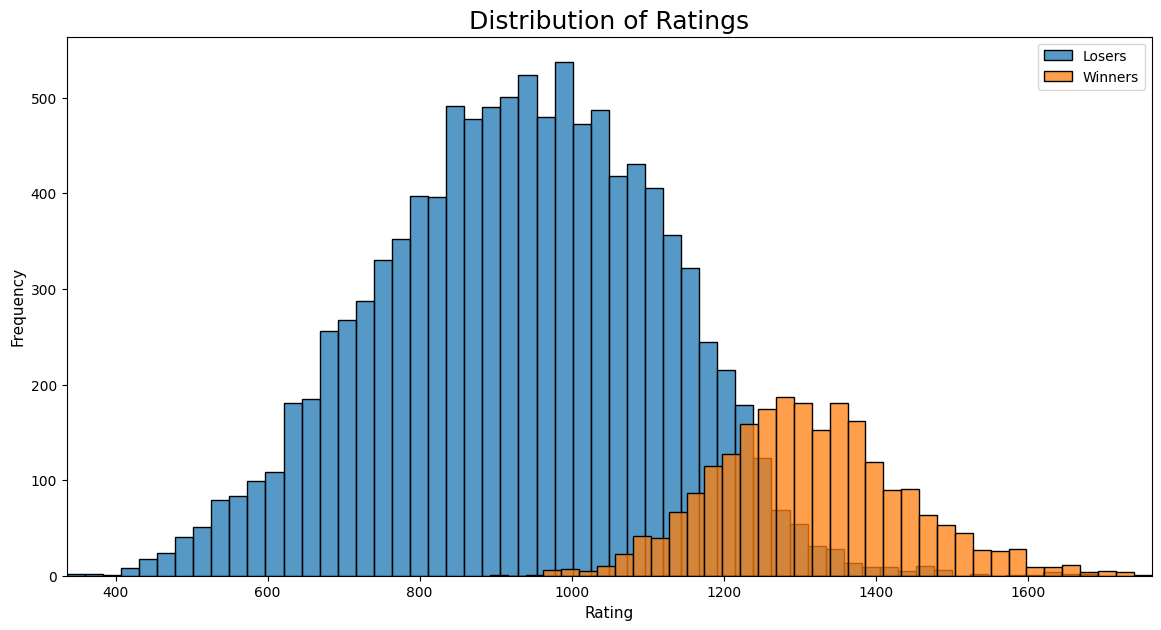

In [ ]:
#Histogram for Distribution of Ratings for Winners and Losers
plt.figure(figsize = (14, 7))

sb.histplot(tounreyMergedRatings.loc[pd.isnull(tounreyMergedRatings['T1TeamID']), 'Rating'], kde = False, label = 'Losers')
sb.histplot(tounreyMergedRatings.loc[~pd.isnull(tounreyMergedRatings['T1TeamID']), 'Rating'], kde = False, label = 'Winners')

plt.xlabel('Rating', fontsize = 11)
plt.ylabel('Frequency', fontsize = 11)
plt.title('Distribution of Ratings', fontsize = 18)

plt.margins(x = 0)
plt.legend()
plt.show()

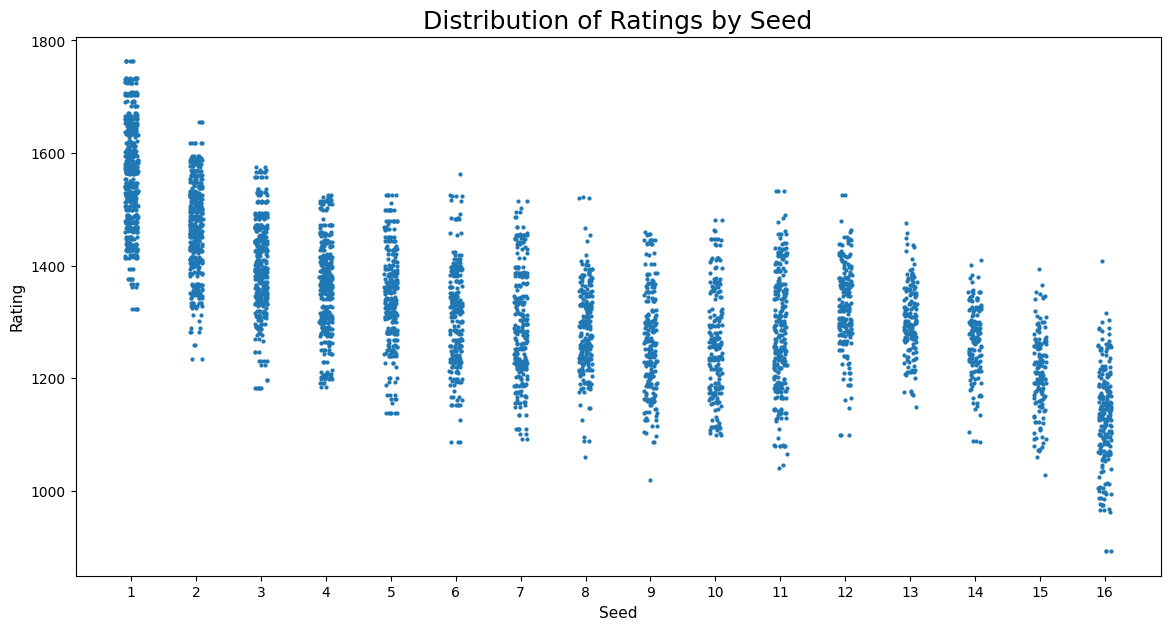

In [ ]:
#Strip Plot of T1Rating vs T1Seed
plt.figure(figsize = (14,7))

sb.stripplot(data = tourneyData, y = 'T1Rating', x = 'T1Seed', size = 3)

plt.xlabel('Seed', fontsize = 11)
plt.ylabel('Rating', fontsize = 11)
plt.title('Distribution of Ratings by Seed', fontsize = 18)

plt.margins(x = 0.05)
plt.show()

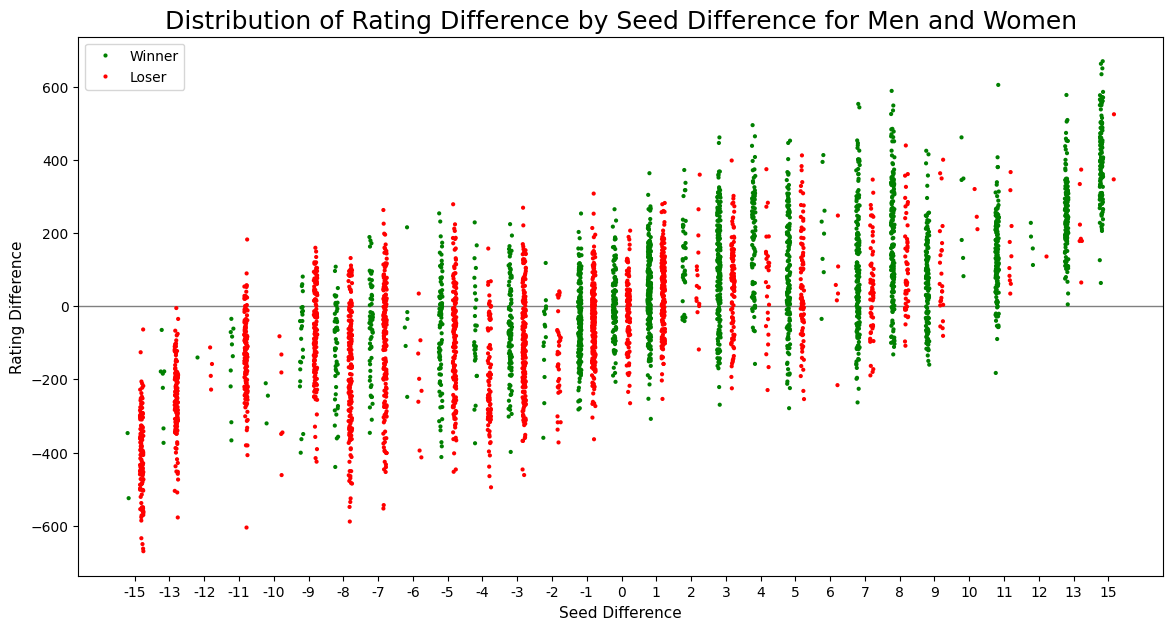

In [ ]:
#Strip Plot for Distribution of Rating Difference by Seed Difference for Men and Women
tourneyData['WinLabel'] = tourneyData['Win'].map({1: 'Winner', 0: 'Loser'})

plt.figure(figsize = (14, 7))

palette = {'Winner': 'green', 'Loser': 'red'}

sb.stripplot(
    data=tourneyData,
    y='RatingDifference',
    x='SeedDifference',
    hue='WinLabel',
    palette=palette,
    dodge=True,
    size=3
)

plt.axhline(0, color='gray', lw=1)

plt.xlabel('Seed Difference', fontsize = 11)
plt.ylabel('Rating Difference', fontsize = 11)
plt.title('Distribution of Rating Difference by Seed Difference for Men and Women', fontsize = 18)

plt.margins(x=0.05)
plt.legend()
plt.show()


4 - Performance Grade Features

In [ ]:
#Create Season + TeamID combinations
seasonData["ST1"] = seasonData.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1TeamID"])), axis = 1)
seasonData["ST2"] = seasonData.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2TeamID"])), axis = 1)
seedsW["ST1"] = seedsW.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1TeamID"])), axis = 1)
seedsL["ST2"] = seedsL.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2TeamID"])), axis = 1)

#Collect Tourney Teams and expand with regular Season upsets
tourneySet = set(seedsW["ST1"]) | set(seedsL["ST2"])
tourneySet = tourneySet | set(seasonData.loc[(seasonData["T1Score"] > seasonData["T2Score"]) & (seasonData["ST2"].isin(tourneySet)), "ST1"])

#Format Team IDs as strings and mask non-Tourney Teams
dataTable = seasonData.loc[(seasonData["ST1"].isin(tourneySet)) | (seasonData["ST2"].isin(tourneySet))].copy()  # Added .copy() here
dataTable["T1TeamID"] = dataTable["T1TeamID"].astype(str)
dataTable["T2TeamID"] = dataTable["T2TeamID"].astype(str)
dataTable.loc[~dataTable["ST1"].isin(tourneySet), "T1TeamID"] = "0000"
dataTable.loc[~dataTable["ST2"].isin(tourneySet), "T2TeamID"] = "0000"

#GLM Team Grade Function
def teamGrade(season, Divison):
    formula = "PointDifference~-1+T1TeamID+T2TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dataTable.loc[(dataTable["Season"] == season) & (dataTable["Divison"] == Divison), :],
        family=sm.families.Gaussian(),
    ).fit()

    grade = pd.DataFrame(glm.params).reset_index()
    grade.columns = ["TeamID", "Grade"]
    grade["Grade"] = grade["Grade"]
    grade["Season"] = season
    grade = grade.loc[grade.TeamID.str.contains("T1")].reset_index(drop=True)
    grade["TeamID"] = grade["TeamID"].apply(lambda x: int(re.findall(r'\d{4}', x)[0]) if re.findall(r'\d{4}', x) else -1)

    return grade

#Build GLM Grade Table across all Seasons
glmGrade = []

seasons = sorted(set(seeds["Season"]))
for season in tqdm.tqdm(seasons, unit="season"):
    if season >= 2010:  # Min season for women
        glmGrade.append(teamGrade(season, 0))
    if season >= 2003:  # Min season for men
        glmGrade.append(teamGrade(season, 1))

glmGrade = pd.concat(glmGrade).reset_index(drop=True)

# erge back into tourneyData
glmGradeT1 = glmGrade.copy()
glmGradeT2 = glmGrade.copy()
glmGradeT1.columns = ["T1TeamID", "T1Grade", "Season"]
glmGradeT2.columns = ["T2TeamID", "T2Grade", "Season"]
tourneyData = pd.merge(tourneyData, glmGradeT1, on = ["Season", "T1TeamID"], how = "left")
tourneyData = pd.merge(tourneyData, glmGradeT2, on = ["Season", "T2TeamID"], how = "left")
tourneyData["GradeDifference"] = tourneyData["T1Grade"] - tourneyData["T2Grade"]

100%|██████████| 22/22 [03:34<00:00,  9.73s/season]


In [ ]:
tourneyData

,Season,T1TeamID,T2TeamID,PointDifference,Win,Divison,T1Seed,T2Seed,SeedDifference,T1AverageScore,T1AverageFGM,T1AverageFGA,T1AverageFGM3,T1AverageFGA3,T1AverageFTM,T1AverageFTA,T1AverageOR,T1AverageDR,T1AverageAst,T1AverageTO,T1AverageStl,T1AverageBlk,T1AveragePF,T1AverageOpponentScore,T1AverageOpponentFGM,T1AverageOpponentFGA,T1AverageOpponentFGM3,T1AverageOpponentFGA3,T1AverageOpponentFTM,T1AverageOpponentFTA,T1AverageOpponentOR,T1AverageOpponentDR,T1AverageOpponentAst,T1AverageOpponentTO,T1AverageOpponentStl,T1AverageOpponentBlk,T1AverageOpponentPF,T1AveragePointDifference,T2AverageScore,T2AverageFGM,T2AverageFGA,T2AverageFGM3,T2AverageFGA3,T2AverageFTM,T2AverageFTA,T2AverageOR,T2AverageDR,T2AverageAst,T2AverageTO,T2AverageStl,T2AverageBlk,T2AveragePF,T2AverageOpponentScore,T2AverageOpponentFGM,T2AverageOpponentFGA,T2AverageOpponentFGM3,T2AverageOpponentFGA3,T2AverageOpponentFTM,T2AverageOpponentFTA,T2AverageOpponentOR,T2AverageOpponentDR,T2AverageOpponentAst,T2AverageOpponentTO,T2AverageOpponentStl,T2AverageOpponentBlk,T2AverageOpponentPF,T2AveragePointDifference,T1Rating,T2Rating,RatingDifference,WinLabel,T1Grade,T2Grade,GradeDifference
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148,1004.511285,1006.068840,-1.557555,Winner,-3.099741,2.115495,-5.215236
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655,1428.100063,1163.408934,264.691130,Winner,27.707625,8.728406,18.979218
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487,1169.181611,1344.907733,-175.726122,Winner,19.701429,19.004846,0.696583
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990,1358.162841,1382.642338,-24.479498,Winner,10.679634,20.664199,-9.984565
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092

In [ ]:
tournryMergedGrades = (
    tourneyData[["Season", "Divison", "T1Seed", "T1Grade"]]
    .drop_duplicates()
    .sort_values("T1Grade")
    .reset_index(drop=True)
)

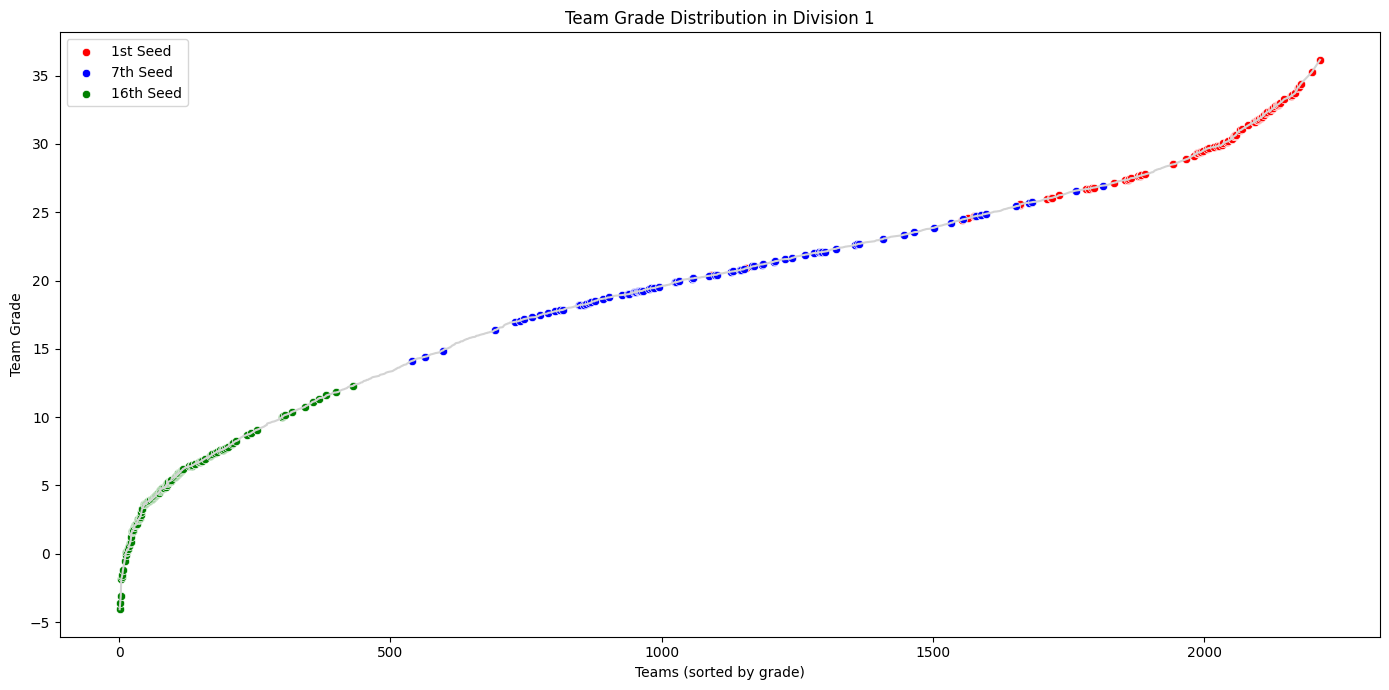

In [ ]:
#Women's Team Grade Distribustion
fig, axs = plt.subplots(figsize=(14, 7))

sb.lineplot(
    data = tournryMergedGrades.loc[tournryMergedGrades["Divison"] == 1, :],
    x = tournryMergedGrades.loc[tournryMergedGrades["Divison"] == 1, :].index,
    y = "T1Grade",
    color = "lightgray",
    ax = axs
)
sb.scatterplot(
    data = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 1) & (tournryMergedGrades.T1Seed == 1)],
    x = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 1) & (tournryMergedGrades.T1Seed == 1)].index,
    y = "T1Grade",
    color = "red",
    ax = axs,
    label = "1st Seed"
)
sb.scatterplot(
    data = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 1) & (tournryMergedGrades.T1Seed == 7)],
    x = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 1) & (tournryMergedGrades.T1Seed == 7)].index,
    y = "T1Grade",
    color = "blue",
    ax = axs,
    label = "7th Seed"
)
sb.scatterplot(
    data = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 1) & (tournryMergedGrades.T1Seed == 16)],
    x = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 1) & (tournryMergedGrades.T1Seed == 16)].index,
    y = "T1Grade",
    color = "green",
    ax = axs,
    label = "16th Seed"
)

axs.set_xlabel("Teams (sorted by grade)")
axs.set_ylabel("Team Grade")
axs.set_title("Team Grade Distribution in Division 1")
axs.legend()

plt.tight_layout()
plt.show()


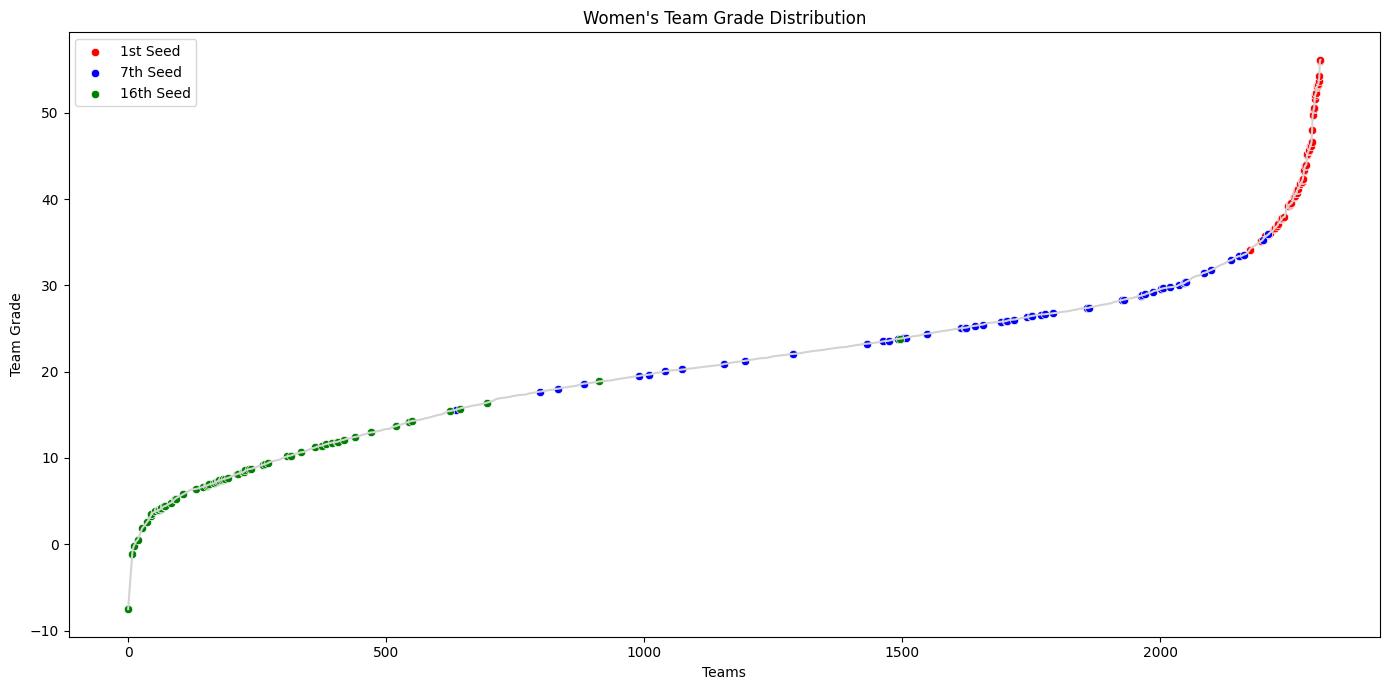

In [ ]:
#Women's Team Grade Distribustion
fig, axs = plt.subplots(figsize=(14, 7))
sb.lineplot(
    data = tournryMergedGrades.loc[tournryMergedGrades["Divison"] == 0, :],
    x = tournryMergedGrades.loc[tournryMergedGrades["Divison"] == 0, :].index,
    y = "T1Grade",
    color = "lightgray",
    ax = axs
)
sb.scatterplot(
    data = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 0) & (tournryMergedGrades.T1Seed == 1)],
    x = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 0) & (tournryMergedGrades.T1Seed == 1)].index,
    y = "T1Grade",
    color = "red",
    ax = axs,
    label = "1st Seed"
)
sb.scatterplot(
    data = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 0) & (tournryMergedGrades.T1Seed == 7)],
    x = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 0) & (tournryMergedGrades.T1Seed == 7)].index,
    y = "T1Grade",
    color = "blue",
    ax = axs,
    label = "7th Seed"
)
sb.scatterplot(
    data = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 0) & (tournryMergedGrades.T1Seed == 16)],
    x = tournryMergedGrades.loc[(tournryMergedGrades["Divison"] == 0) & (tournryMergedGrades.T1Seed == 16)].index,
    y = "T1Grade",
    color = "green",
    ax = axs,
    label = "16th Seed"
)

axs.set_xlabel("Teams")
axs.set_ylabel("Team Grade")
axs.set_title("Women's Team Grade Distribution")
axs.legend()

plt.tight_layout()
plt.show()


In [ ]:
tournryMergedGrades["GradeSeed"] = (
    (tournryMergedGrades.groupby(["Season", "Divison"])["T1Grade"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)
pd.pivot_table(
    data = tournryMergedGrades,
    index = "T1Seed",
    columns = "GradeSeed",
    values = "Divison",
    aggfunc = "count"
).fillna(0).astype(int).style.bar(color = "#2f7a04", vmin = 0, vmax = 50)

GradeSeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1Seed,,,,,,,,,,,,,,,,
1,75,45,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,49,42,20,5,4,2,0,0,0,0,0,0,0,0,0
3,6,16,33,30,26,16,5,3,0,4,1,0,0,0,0,0
4,5,15,22,25,18,21,19,9,3,2,1,0,0,0,0,0
5,0,6,14,25,20,19,22,14,7,4,7,2,0,0,0,0
6,1,3,7,13,23,29,14,19,10,10,6,4,1,0,0,0
7,0,2,3,6,18,12,19,22,22,14,12,8,2,0,0,0
8,0,0,3,6,6,17,19,20,19,22,15,6,7,0,0,0
9,0,2,0,6,10,7,12,17,25,24,19,11,5,1,1,0


In [ ]:
#Compute AUC Values
seedAuc = roc_auc_score(1 - tourneyData["Win"], tourneyData["T1Seed"] - tourneyData["T2Seed"])
gradeAuc = roc_auc_score(tourneyData["Win"], tourneyData["T1Grade"] - tourneyData["T2Grade"])

aucDF = pd.DataFrame([[seedAuc, gradeAuc]], columns = ["Seed AUC", "Grade AUC"])

aucDF.style.hide(axis = "index")

Seed AUC,Grade AUC
0.806930,0.825115


In [ ]:
#Collect AUC Values by Season
results = []
for season in sorted(set(tourneyData["Season"])):
    tourneySet = tourneyData["Season"] == season
    seedAuc = np.round(
        roc_auc_score(1 - tourneyData.loc[tourneySet, "Win"],
        tourneyData.loc[tourneySet, "T1Seed"] - tourneyData.loc[tourneySet, "T2Seed"]),
        3
    )
    gradeAuc = np.round(
        roc_auc_score(tourneyData.loc[tourneySet, "Win"],
        tourneyData.loc[tourneySet, "T1Grade"] - tourneyData.loc[tourneySet, "T2Grade"]),
        3
    )
    better = "Seed" if seedAuc > gradeAuc else "Grade"
    results.append([season, seedAuc, gradeAuc, better])

aucCompareDF = pd.DataFrame(results, columns = ["Season", "Seed AUC", "Grade AUC", "Better"])

aucCompareDF.style.format({"Seed AUC": "{:.3f}", "Grade AUC": "{:.3f}"}).hide(axis = "index")

Season,Seed AUC,Grade AUC,Better
2003,0.807,0.779,Seed
2004,0.823,0.810,Seed
2005,0.792,0.811,Grade
2006,0.750,0.781,Grade
2007,0.902,0.838,Seed
2008,0.817,0.851,Grade
2009,0.840,0.843,Grade
2010,0.804,0.808,Grade
2011,0.789,0.816,Grade
2012,0.828,0.855,Grade


In [ ]:
tourneyData["DivisonLabel"] = np.where(tourneyData["Divison"] == 1, "M", "W")

In [ ]:
tourneyData

,Season,T1TeamID,T2TeamID,PointDifference,Win,Divison,T1Seed,T2Seed,SeedDifference,T1AverageScore,T1AverageFGM,T1AverageFGA,T1AverageFGM3,T1AverageFGA3,T1AverageFTM,T1AverageFTA,T1AverageOR,T1AverageDR,T1AverageAst,T1AverageTO,T1AverageStl,T1AverageBlk,T1AveragePF,T1AverageOpponentScore,T1AverageOpponentFGM,T1AverageOpponentFGA,T1AverageOpponentFGM3,T1AverageOpponentFGA3,T1AverageOpponentFTM,T1AverageOpponentFTA,T1AverageOpponentOR,T1AverageOpponentDR,T1AverageOpponentAst,T1AverageOpponentTO,T1AverageOpponentStl,T1AverageOpponentBlk,T1AverageOpponentPF,T1AveragePointDifference,T2AverageScore,T2AverageFGM,T2AverageFGA,T2AverageFGM3,T2AverageFGA3,T2AverageFTM,T2AverageFTA,T2AverageOR,T2AverageDR,T2AverageAst,T2AverageTO,T2AverageStl,T2AverageBlk,T2AveragePF,T2AverageOpponentScore,T2AverageOpponentFGM,T2AverageOpponentFGA,T2AverageOpponentFGM3,T2AverageOpponentFGA3,T2AverageOpponentFTM,T2AverageOpponentFTA,T2AverageOpponentOR,T2AverageOpponentDR,T2AverageOpponentAst,T2AverageOpponentTO,T2AverageOpponentStl,T2AverageOpponentBlk,T2AverageOpponentPF,T2AveragePointDifference,T1Rating,T2Rating,RatingDifference,WinLabel,T1Grade,T2Grade,GradeDifference,DivisonLabel
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148,1004.511285,1006.068840,-1.557555,Winner,-3.099741,2.115495,-5.215236,M
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655,1428.100063,1163.408934,264.691130,Winner,27.707625,8.728406,18.979218,M
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487,1169.181611,1344.907733,-175.726122,Winner,19.701429,19.004846,0.696583,M
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990,1358.162841,1382.642338,-24.479498,Winner,10.679634,20.664199,-9.984565,M
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.11494

In [ ]:
#Prepare DataFrame for Export
tourneyData = tourneyData[
    [
        "Season",

        "T1TeamID",
        "T2TeamID",

        "T1AverageScore",
        "T2AverageScore",
        "PointDifference",

        "T1Seed",
        "T2Seed",
        "SeedDifference",

        "T1Rating",
        "T2Rating",
        "RatingDifference",

        "T1Grade",
        "T2Grade",
        "GradeDifference",

        "Divison",
        "DivisonLabel",

        "Win",
        "WinLabel",

        "T1AverageFGM",
        "T1AverageFGA",
        "T1AverageFGM3",
        "T1AverageFGA3",
        "T1AverageFTM",
        "T1AverageFTA",
        "T1AverageOR",
        "T1AverageDR",
        "T1AverageAst",
        "T1AverageTO",
        "T1AverageStl",
        "T1AverageBlk",
        "T1AveragePF",
        "T1AverageOpponentScore",
        "T1AverageOpponentFGM",
        "T1AverageOpponentFGA",
        "T1AverageOpponentFGM3",
        "T1AverageOpponentFGA3",
        "T1AverageOpponentFTM",
        "T1AverageOpponentFTA",
        "T1AverageOpponentOR",
        "T1AverageOpponentDR",
        "T1AverageOpponentAst",
        "T1AverageOpponentTO",
        "T1AverageOpponentStl",
        "T1AverageOpponentBlk",
        "T1AverageOpponentPF",
        "T1AveragePointDifference",

        "T2AverageFGM",
        "T2AverageFGA",
        "T2AverageFGM3",
        "T2AverageFGA3",
        "T2AverageFTM",
        "T2AverageFTA",
        "T2AverageOR",
        "T2AverageDR",
        "T2AverageAst",
        "T2AverageTO",
        "T2AverageStl",
        "T2AverageBlk",
        "T2AveragePF",
        "T2AverageOpponentScore",
        "T2AverageOpponentFGM",
        "T2AverageOpponentFGA",
        "T2AverageOpponentFGM3",
        "T2AverageOpponentFGA3",
        "T2AverageOpponentFTM",
        "T2AverageOpponentFTA",
        "T2AverageOpponentOR",
        "T2AverageOpponentDR",
        "T2AverageOpponentAst",
        "T2AverageOpponentTO",
        "T2AverageOpponentStl",
        "T2AverageOpponentBlk",
        "T2AverageOpponentPF",
        "T2AveragePointDifference",
    ]
]

In [ ]:
tourneyData

,Season,T1TeamID,T2TeamID,T1AverageScore,T2AverageScore,PointDifference,T1Seed,T2Seed,SeedDifference,T1Rating,T2Rating,RatingDifference,T1Grade,T2Grade,GradeDifference,Divison,DivisonLabel,Win,WinLabel,T1AverageFGM,T1AverageFGA,T1AverageFGM3,T1AverageFGA3,T1AverageFTM,T1AverageFTA,T1AverageOR,T1AverageDR,T1AverageAst,T1AverageTO,T1AverageStl,T1AverageBlk,T1AveragePF,T1AverageOpponentScore,T1AverageOpponentFGM,T1AverageOpponentFGA,T1AverageOpponentFGM3,T1AverageOpponentFGA3,T1AverageOpponentFTM,T1AverageOpponentFTA,T1AverageOpponentOR,T1AverageOpponentDR,T1AverageOpponentAst,T1AverageOpponentTO,T1AverageOpponentStl,T1AverageOpponentBlk,T1AverageOpponentPF,T1AveragePointDifference,T2AverageFGM,T2AverageFGA,T2AverageFGM3,T2AverageFGA3,T2AverageFTM,T2AverageFTA,T2AverageOR,T2AverageDR,T2AverageAst,T2AverageTO,T2AverageStl,T2AverageBlk,T2AveragePF,T2AverageOpponentScore,T2AverageOpponentFGM,T2AverageOpponentFGA,T2AverageOpponentFGM3,T2AverageOpponentFGA3,T2AverageOpponentFTM,T2AverageOpponentFTA,T2AverageOpponentOR,T2AverageOpponentDR,T2AverageOpponentAst,T2AverageOpponentTO,T2AverageOpponentStl,T2AverageOpponentBlk,T2AverageOpponentPF,T2AveragePointDifference
0,2003,1421,1411,69.615326,72.533333,7.111111,16,16,0,1004.511285,1006.068840,-1.557555,-3.099741,2.115495,-5.215236,1,M,1,Winner,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,84.511905,67.255172,29.000000,1,16,15,1428.100063,1163.408934,264.691130,27.707625,8.728406,18.979218,1,M,1,Winner,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,75.344828,74.210728,13.000000,10,7,-3,1169.181611,1344.907733,-175.726122,19.701429,19.004846,0.696583,1,M,1,Winner,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,79.344828,79.006734,6.000000,11,6,-5,1358.162841,1382.642338,-24.479498,10.679634,20.664199,-9.984565,1,M,1,Winner,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,73.636015,72.122222,1.777778,8,9,1,1174.931676,1237.862564,-62.930889,16.066839,21.121888,-5.055

In [ ]:
#Prepare a set of data to be predicted on
predictionsMerged = pd.read_csv("raw/SampleSubmissionStage2.csv")
predictionsMerged['Season'] = predictionsMerged['ID'].apply(lambda t: int(t.split('_')[0]))
predictionsMerged['T1TeamID'] = predictionsMerged['ID'].apply(lambda t: int(t.split('_')[1]))
predictionsMerged['T2TeamID'] = predictionsMerged['ID'].apply(lambda t: int(t.split('_')[2]))
predictionsMerged['men_women'] = predictionsMerged['T1TeamID'].apply(lambda t: 0 if str(t)[0]=='1' else 1)
predictionsMerged = pd.merge(predictionsMerged, seasonAggregateT1, on = ['Season', 'T1TeamID'], how = 'left')
predictionsMerged = pd.merge(predictionsMerged, seasonAggregateT2, on = ['Season', 'T2TeamID'], how = 'left')
predictionsMerged = pd.merge(predictionsMerged, seedsW, on = ['Season', 'T1TeamID'], how = 'left')
predictionsMerged = pd.merge(predictionsMerged, seedsL, on = ['Season', 'T2TeamID'], how = 'left')
predictionsMerged = pd.merge(predictionsMerged, glmGradeT1, on=["Season", "T1TeamID"], how="left")
predictionsMerged = pd.merge(predictionsMerged, glmGradeT2, on=["Season", "T2TeamID"], how="left")
predictionsMerged = pd.merge(predictionsMerged, ratingsT1, on=["Season", "T1TeamID"], how="left")
predictionsMerged = pd.merge(predictionsMerged, ratingsT2, on=["Season", "T2TeamID"], how="left")
predictionsMerged["SeedDifference"] = predictionsMerged["T2Seed"] - predictionsMerged["T1Seed"]
predictionsMerged["RatingDifference"] = predictionsMerged["T1Rating"] - predictionsMerged["T2Rating"]
predictionsMerged["GradeDifference"] = predictionsMerged["T1Grade"] - predictionsMerged["T2Grade"]

In [ ]:
predictionsMerged.to_csv('/content/predictionsMerged.csv', index=None)
seasonAggregateT1.to_csv('/content/seasonAggregateT1.csv', index=None)
seasonAggregateT2.to_csv('/content/seasonAggregateT2.csv', index=None)
seedsW.to_csv('/content/seedsW.csv', index=None)
seedsL.to_csv('/content/seedsL.csv', index=None)
glmGradeT1.to_csv('/content/glmGradeT1.csv', index=None)
glmGradeT2.to_csv('/content/glmGradeT2.csv', index=None)
ratingsT1.to_csv('/content/ratingsT1.csv', index=None)
ratingsT2.to_csv('/content/ratingsT2.csv', index=None)

In [145]:
from google.colab import files
predictionsMerged.to_csv('predictionsMerged.csv', index=False)
files.download('predictionsMerged.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
####################################### READ ##############################################
############## IF RUNNING THIS THEN REPLACE MY EMAIL AND USERNAME WITH YOURS ##############
### ALSO U NEED A TEXT FILE OF YOUR TOKEN NAMED "github_token.txt" INSIDE OF YOUR DRIVE ###
####################################### READ ##############################################

# Read the token from Drive
drive.mount('/content/drive')
with open('/content/drive/My Drive/github_token.txt') as f:
    token = f.read().strip()

# Git Config
!git config --global user.email "rajaropen@gmail.com"
!git config --global user.name "NeedRam"

# Clone repo
repo_url = f"https://{token}@github.com/jamie07262/INFO-3608-PROJECT.git"
!git clone {repo_url}

# Save the Features Table to a CSV file
tourneyData.to_csv("NewFeaturesForPredictions.csv", index=False)

# Move the processed files to the repo
shutil.move("NewFeaturesForPredictions.csv", "INFO-3608-PROJECT/data/processed/NewFeaturesForPredictions.csv")

# Commit and push the change
%cd INFO-3608-PROJECT
!git add data/processed/NewFeaturesForPredictions.csv
!git commit -m "Add processed data NewFeaturesForPredictions CSV"
!git push